# Parks Canada Weather Station – Analysis Notebook
## DATA-3210: Meteorological Network Optimization & Predictive Modeling

This notebook documents the complete analysis pipeline:
1. **EDA** – Exploratory Data Analysis of scrubbed hourly data
2. **PCA / Clustering** – Station redundancy analysis
3. **FWI** – Fire Weather Index calculation and ECCC validation
4. **Probabilistic Uncertainty** – KDE risk assessment for station removal

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='tab10')

ROOT = Path('.').resolve()
SCRUBBED = ROOT / 'data' / 'scrubbed'
FIGURES = ROOT / 'outputs' / 'figures'

CORE_COLS = ['temp_c', 'rh_pct', 'rain_mm', 'wind_speed_kmh', 'solar_rad_wm2']

In [2]:
# Load all scrubbed hourly station data
frames = []
for pq in sorted(SCRUBBED.glob('*.parquet')):
    if 'fwi' in pq.stem or pq.stem == 'missing_value_report':
        continue
    df = pd.read_parquet(pq)
    frames.append(df)

data = pd.concat(frames)
print(f'Total rows: {len(data):,}')
print(f'Stations: {data["station"].unique()}')
print(f'Date range: {data.index.min()} → {data.index.max()}')

Total rows: 156,971
Stations: <ArrowStringArray>
[           'Cavendish',      'Stanhope (ECCC)',            'Greenwich',
  'North Rustico Wharf', 'Stanley Bridge Wharf',       'Tracadie Wharf']
Length: 6, dtype: str
Date range: 2022-01-01 04:00:00+00:00 → 2026-01-01 03:00:00+00:00


---
## 1. Exploratory Data Analysis (EDA)

In [3]:
# Descriptive statistics by station
cols = [c for c in CORE_COLS if c in data.columns]
data.groupby('station')[cols].describe().round(2)

temp_c                                                 \
                        count  mean    std    min   25%    50%    75%    max   
station                                                                        
Cavendish             25022.0  8.11   9.99 -27.01  0.18   7.86  16.33  35.32   
Greenwich             18463.0  7.45  10.27 -46.85 -0.49   6.38  15.96  34.26   
North Rustico Wharf   23101.0  8.62   9.67 -20.86  1.25   8.42  16.71  33.49   
Stanhope (ECCC)       34623.0  7.67   9.98 -26.70  0.00   6.90  16.30  34.60   
Stanley Bridge Wharf  19770.0  9.59   9.67 -20.41  1.55  10.26  17.40  39.63   
Tracadie Wharf        20648.0  8.61  10.07 -21.13  0.55   8.15  17.57  33.75   

                       rh_pct         ... wind_speed_kmh        solar_rad_wm2  \
                        count   mean  ...            75%    max         count   
station                               ...                                       
Cavendish             25022.0  79.84  ...          16.17  51.20       25022.0   
Greenwich             20458.0  81.45  ...          12.00  44.25       25861.0   
North Rustico Wharf   23101.0  79.86  ...          17.70  49.93       23818.0   
Stanhope (ECCC)       34623.0  78.34  ...          18.00  89.00           0.0   
Stanley Bridge Wharf      0.0    NaN  ...          17.43  61.43       21049.0   
Tracadie Wharf            0.0    NaN  ...          22.10  59.77       20648.0   

                                                                      
                        mean     std  min  25%   50%     75%     max  
station                                                               
Cavendish             136.03  211.87  1.0  1.0  6.60  202.48  963.93  
Greenwich             137.57  223.10  1.0  1.0  4.58  191.13  999.00  
North Rustico Wharf   144.82  226.80  1.0  1.0  7.50  212.65  993.11  
Stanhope (ECCC)          NaN     NaN  NaN  NaN   NaN     NaN     NaN  
Stanley Bridge Wharf  128.84  207.36  1.0  1.0  4.50  183.60  966.46  
Tracadie Wharf        134.69  213.92  1.0  1.0  5.60  193.43  925.77  

[6 rows x 40 columns]

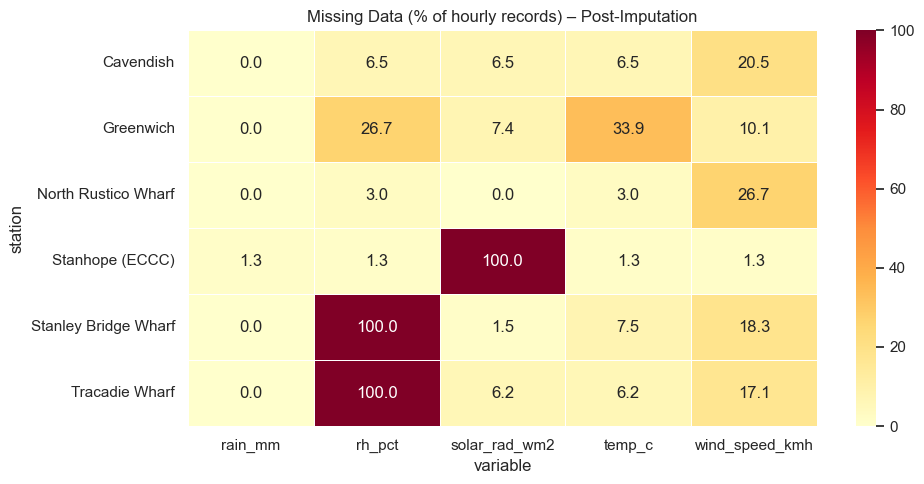

In [4]:
# Missing data heatmap
stations = data['station'].unique()
miss_records = []
for stn in stations:
    sub = data[data['station'] == stn]
    total = len(sub)
    for col in cols:
        pct = sub[col].isna().sum() / total * 100 if total else 0
        miss_records.append({'station': stn, 'variable': col, 'pct_missing': pct})

miss = pd.DataFrame(miss_records).pivot(index='station', columns='variable', values='pct_missing')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(miss, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Missing Data (% of hourly records) – Post-Imputation')
plt.tight_layout()
plt.show()

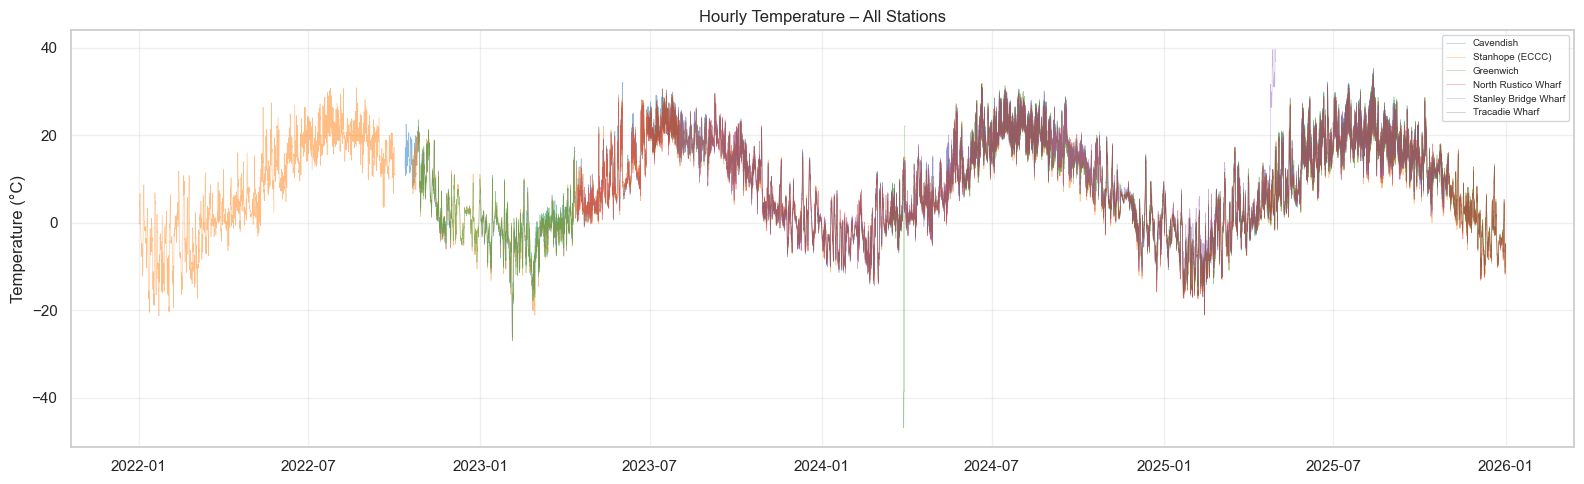

In [5]:
# Time-series overlay – Temperature
fig, ax = plt.subplots(figsize=(16, 5))
for stn in stations:
    sub = data[data['station'] == stn]
    ax.plot(sub.index, sub['temp_c'], label=stn, alpha=0.5, linewidth=0.4)
ax.set_ylabel('Temperature (°C)')
ax.set_title('Hourly Temperature – All Stations')
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

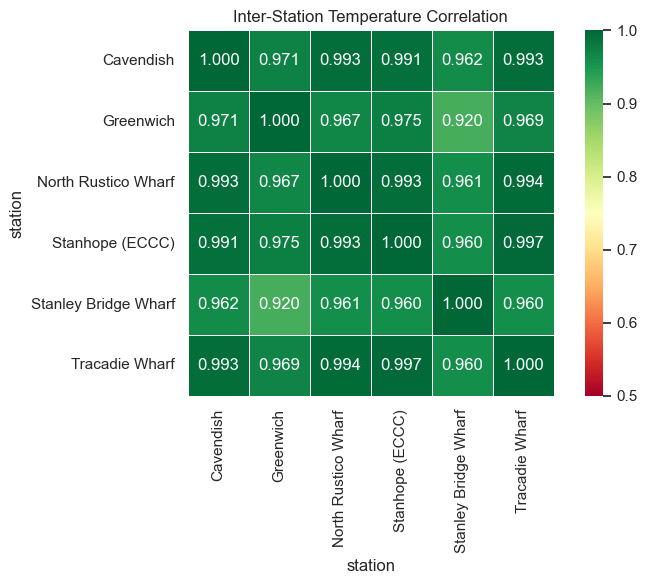

In [6]:
# Inter-station correlation heatmap – Temperature
pivot = data.pivot_table(index=data.index, columns='station', values='temp_c')
corr = pivot.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1.0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Inter-Station Temperature Correlation')
plt.tight_layout()
plt.show()

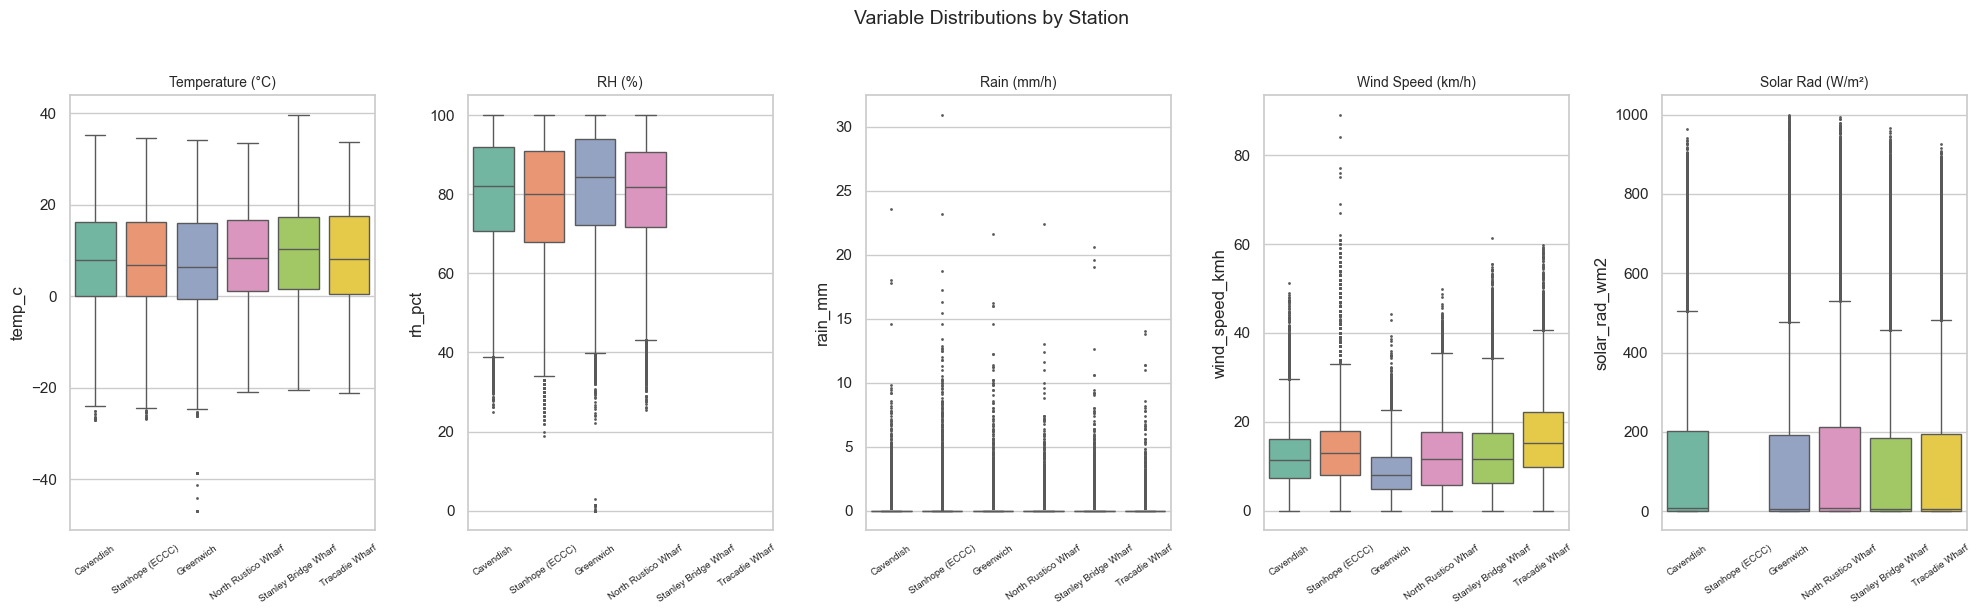

In [7]:
# Box plots comparing distributions across stations
fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 6))
labels = {'temp_c': 'Temperature (°C)', 'rh_pct': 'RH (%)', 'rain_mm': 'Rain (mm/h)',
          'wind_speed_kmh': 'Wind Speed (km/h)', 'solar_rad_wm2': 'Solar Rad (W/m²)'}
df_reset = data.reset_index(drop=True)
for ax, col in zip(axes, cols):
    sns.boxplot(data=df_reset, x='station', y=col, hue='station',
                ax=ax, palette='Set2', fliersize=1, legend=False)
    ax.set_title(labels.get(col, col), fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35, labelsize=7)
fig.suptitle('Variable Distributions by Station', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Redundancy Analysis – PCA & Clustering (LO 3)

In [8]:
# ECCC Benchmark – Correlation with Stanhope reference
bench = pd.read_csv(ROOT / 'outputs' / 'eccc_benchmark.csv')
bench

,station,temp_c_corr,rh_pct_corr,rain_mm_corr,wind_speed_kmh_corr,solar_rad_wm2_corr,high_corr_count,redundancy_flag
0,Cavendish,0.991356,0.920539,0.378959,0.800190,NaN,2.0,MARGINAL
1,Greenwich,0.974690,0.832964,0.516682,0.767378,NaN,1.0,UNIQUE
2,North Rustico Wharf,0.993386,0.912964,0.472979,0.497452,NaN,2.0,MARGINAL
3,Stanley Bridge Wharf,0.960020,NaN,0.389085,0.799269,NaN,1.0,UNIQUE
4,Tracadie Wharf,0.997008,NaN,0.491845,0.886764,NaN,1.0,UNIQUE


In [9]:
# PCA on daily weather features
pca_cols = [c for c in CORE_COLS if c in data.columns]
daily_records = []
for stn in stations:
    sub = data[data['station'] == stn]
    daily = sub[pca_cols].resample('1D').mean().dropna()
    for _, day_row in daily.iterrows():
        rec = {'station': stn}
        for c in pca_cols:
            rec[c] = day_row[c]
        daily_records.append(rec)

feat_df = pd.DataFrame(daily_records).dropna()
X = feat_df[pca_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['station'] = feat_df['station'].values

print('Explained variance ratio:', pca.explained_variance_ratio_.round(3))
print('Cumulative:', pca.explained_variance_ratio_.cumsum().round(3))

Explained variance ratio: [0.399 0.229 0.204]
Cumulative: [0.399 0.628 0.832]


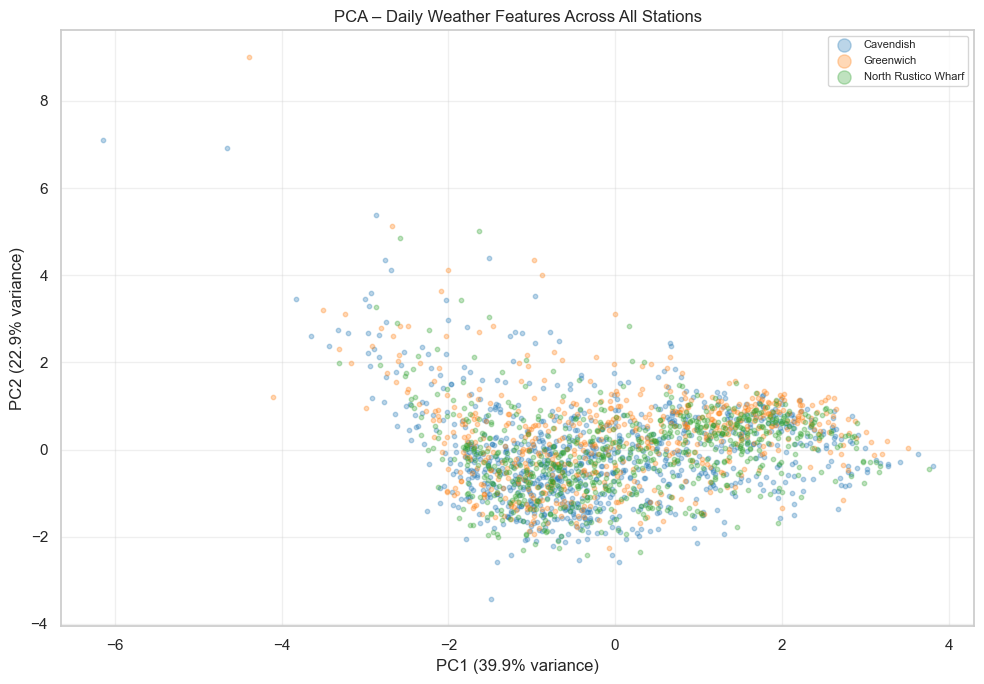

In [10]:
# PCA scatter plot
fig, ax = plt.subplots(figsize=(10, 7))
for stn in pca_df['station'].unique():
    sub = pca_df[pca_df['station'] == stn]
    ax.scatter(sub['PC1'], sub['PC2'], label=stn, alpha=0.3, s=10)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA – Daily Weather Features Across All Stations')
ax.legend(fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

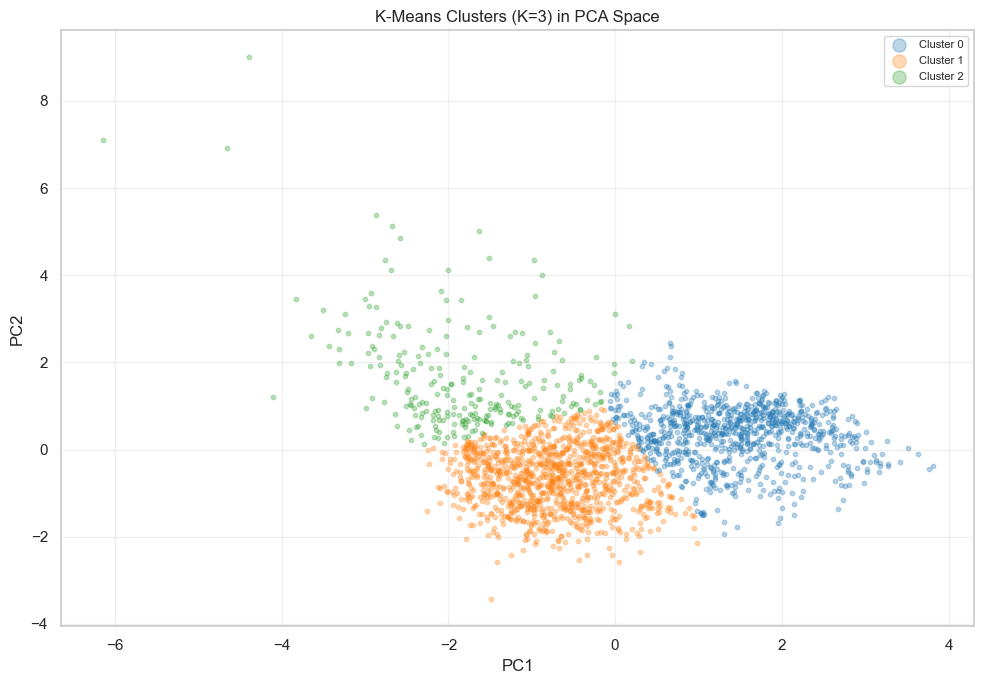


Station → Dominant Cluster:
            station  cluster
          Cavendish        1
          Greenwich        0
North Rustico Wharf        1


In [11]:
# K-Means clustering
km = KMeans(n_clusters=3, n_init=10, random_state=42)
pca_df['cluster'] = km.fit_predict(X_pca[:, :2])

fig, ax = plt.subplots(figsize=(10, 7))
for cl in sorted(pca_df['cluster'].unique()):
    sub = pca_df[pca_df['cluster'] == cl]
    ax.scatter(sub['PC1'], sub['PC2'], label=f'Cluster {cl}', alpha=0.3, s=10)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('K-Means Clusters (K=3) in PCA Space')
ax.legend(fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Dominant cluster per station
summary = pca_df.groupby(['station', 'cluster']).size().reset_index(name='n_days')
dominant = summary.loc[summary.groupby('station')['n_days'].idxmax()]
print('\nStation → Dominant Cluster:')
print(dominant[['station', 'cluster']].to_string(index=False))

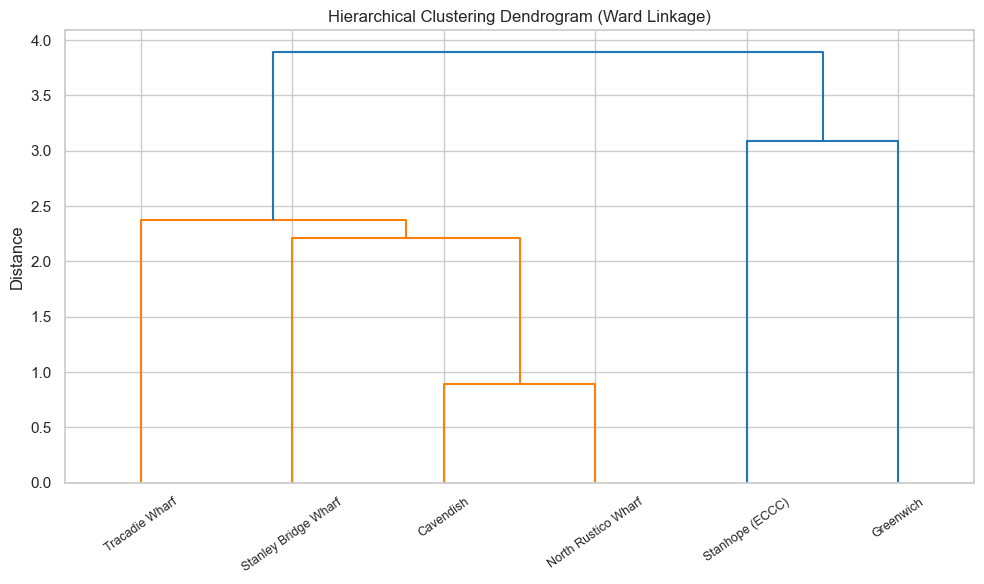

In [12]:
# Hierarchical clustering dendrogram
mean_vecs = []
stn_labels = []
for stn in stations:
    sub = data[data['station'] == stn][pca_cols].mean()
    mean_vecs.append(sub.values)
    stn_labels.append(stn)

mean_df_h = pd.DataFrame(mean_vecs, columns=pca_cols, index=stn_labels).dropna(axis=1)
X_h = StandardScaler().fit_transform(mean_df_h.values)
Z = linkage(X_h, method='ward')

fig, ax = plt.subplots(figsize=(10, 6))
dendrogram(Z, labels=list(mean_df_h.index), ax=ax, leaf_rotation=35, leaf_font_size=9)
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

---
## 3. Fire Weather Index (FWI) – Cavendish & Greenwich

In [13]:
# Load FWI results
fwi_cav = pd.read_parquet(SCRUBBED / 'cavendish_fwi_daily.parquet')
fwi_grn = pd.read_parquet(SCRUBBED / 'greenwich_fwi_daily.parquet')
fwi_eccc = pd.read_parquet(SCRUBBED / 'eccc_stanhope_fwi_daily.parquet')

fwi_cav['station'] = 'Cavendish'
fwi_grn['station'] = 'Greenwich'
fwi_eccc['station'] = 'Stanhope (ECCC)'

fwi_all = pd.concat([fwi_cav, fwi_grn, fwi_eccc])
print(f'FWI records: {len(fwi_all):,}')
fwi_all.groupby('station')[['FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']].describe().round(2)

FWI records: 3,098


FFMC                                                  \
                  count   mean    std   min    25%    50%    75%    max   
station                                                                   
Cavendish        1048.0  48.48  29.24  0.00  23.37  56.23  74.54  87.78   
Greenwich         605.0  56.07  24.06  0.00  38.33  62.06  78.05  86.71   
Stanhope (ECCC)  1445.0  54.75  22.89  0.34  35.78  57.29  76.48  87.53   

                    DMC        ...    BUI            FWI                   \
                  count  mean  ...    75%    max   count  mean   std  min   
station                        ...                                          
Cavendish        1048.0  5.13  ...  12.83  59.54   892.0  1.14  2.31  0.0   
Greenwich         605.0  6.69  ...  18.46  67.05   602.0  1.28  2.13  0.0   
Stanhope (ECCC)  1445.0  4.86  ...  10.97  72.93  1445.0  1.32  2.50  0.0   

                                          
                  25%   50%   75%    max  
station                                   
Cavendish        0.02  0.23  0.72  16.66  
Greenwich        0.01  0.25  1.56  11.53  
Stanhope (ECCC)  0.01  0.20  0.91  16.29  

[3 rows x 48 columns]

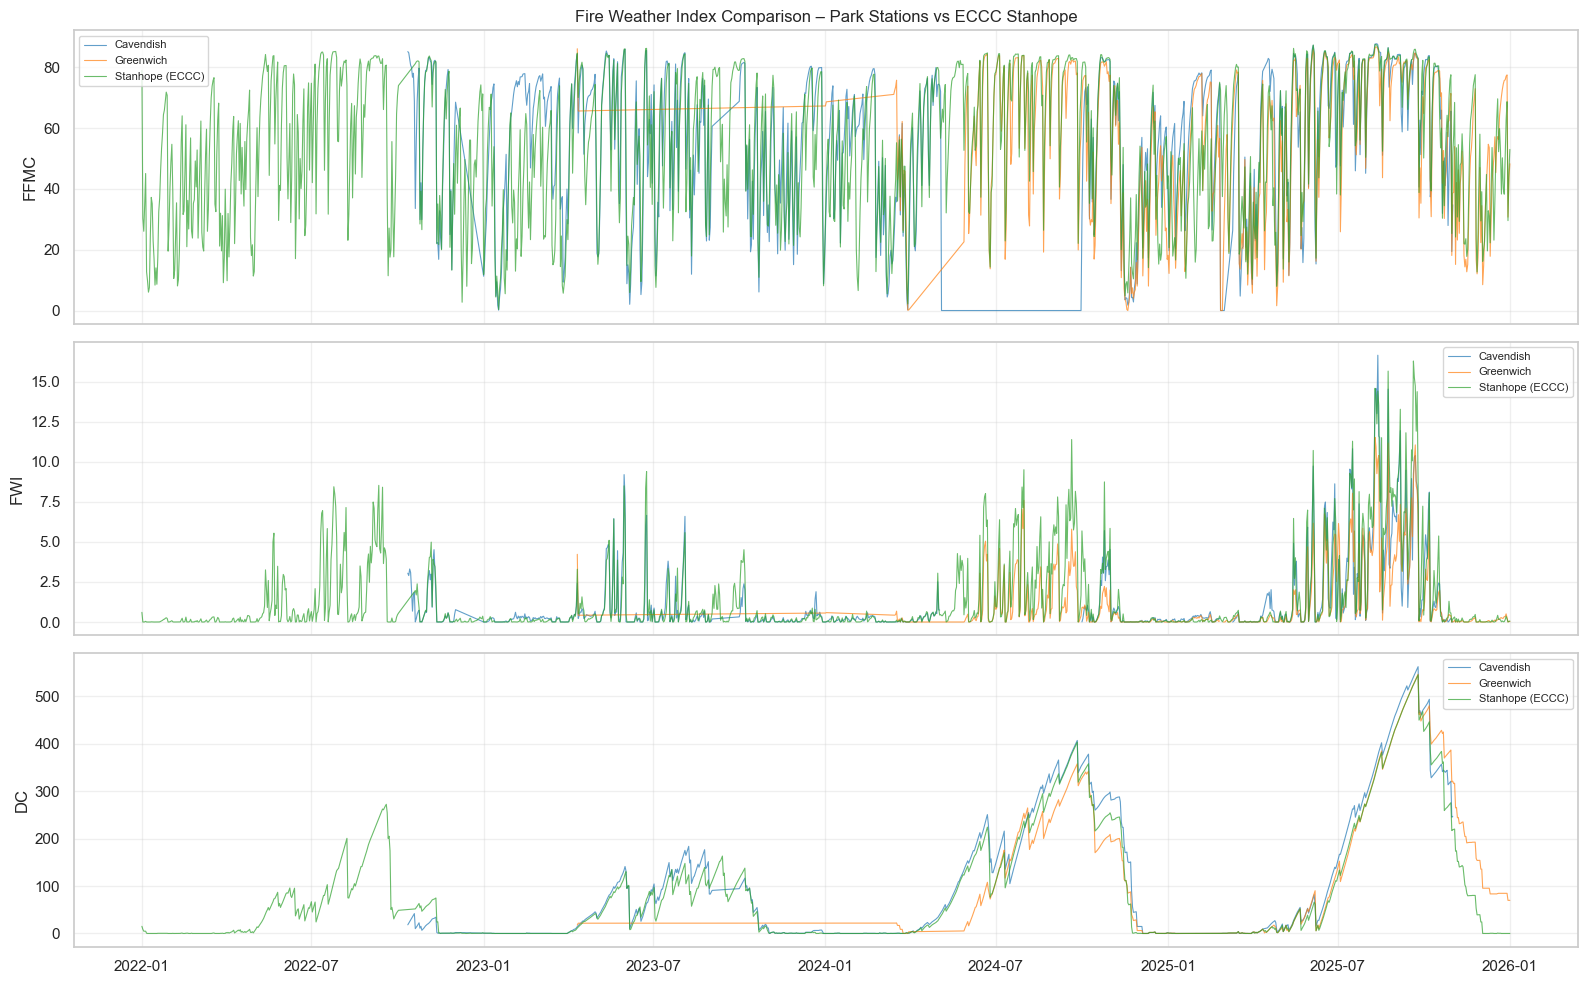

In [14]:
# FWI time series comparison
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
for ax, code in zip(axes, ['FFMC', 'FWI', 'DC']):
    for stn in ['Cavendish', 'Greenwich', 'Stanhope (ECCC)']:
        sub = fwi_all[fwi_all['station'] == stn]
        ax.plot(sub.index, sub[code], label=stn, alpha=0.7, linewidth=0.8)
    ax.set_ylabel(code)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
axes[0].set_title('Fire Weather Index Comparison – Park Stations vs ECCC Stanhope')
plt.tight_layout()
plt.show()

In [15]:
# ECCC FWI validation – correlation
for stn_name, stn_fwi in [('Cavendish', fwi_cav), ('Greenwich', fwi_grn)]:
    merged = stn_fwi[['FWI']].join(fwi_eccc[['FWI']], rsuffix='_eccc', how='inner').dropna()
    if len(merged) > 10:
        r = merged['FWI'].corr(merged['FWI_eccc'])
        print(f'{stn_name} vs ECCC Stanhope FWI correlation: r = {r:.4f}  ({len(merged)} days)')
    else:
        print(f'{stn_name}: insufficient overlap for validation')

Cavendish vs ECCC Stanhope FWI correlation: r = 0.9333  (884 days)
Greenwich vs ECCC Stanhope FWI correlation: r = 0.9364  (602 days)


---
## 4. Probabilistic Uncertainty Analysis (LO 7)

In [16]:
# Load pre-computed risk assessment
risk = pd.read_csv(ROOT / 'outputs' / 'uncertainty_risk.csv')
risk

,station,variable,p_extreme,mean_resid,std_resid,n_obs
0,Cavendish,temp_c,0.0447,-0.173,1.161,24826
1,Cavendish,rain_mm,0.0245,-0.012,0.404,26578
2,Cavendish,wind_speed_kmh,0.0526,-0.402,3.628,21077
3,Stanhope (ECCC),temp_c,0.0443,-0.286,1.044,28043
4,Stanhope (ECCC),rain_mm,0.0258,0.043,0.548,28043
5,Stanhope (ECCC),wind_speed_kmh,0.0457,2.461,4.496,28043
6,Greenwich,temp_c,0.0123,0.066,2.309,18463
7,Greenwich,rain_mm,0.0239,-0.004,0.477,27925
8,Greenwich,wind_speed_kmh,0.0490,-5.079,4.507,25091
9,North Rustico Wharf,temp_c,0.0487,-0.101,1.061,23101


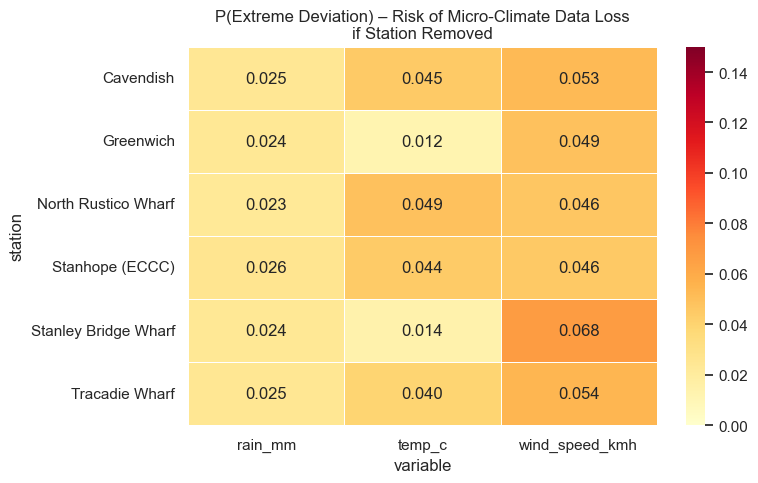

In [17]:
# Risk heatmap
pivot_risk = risk.pivot(index='station', columns='variable', values='p_extreme')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_risk, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, vmin=0, vmax=0.15)
ax.set_title('P(Extreme Deviation) – Risk of Micro-Climate Data Loss\nif Station Removed')
plt.tight_layout()
plt.show()

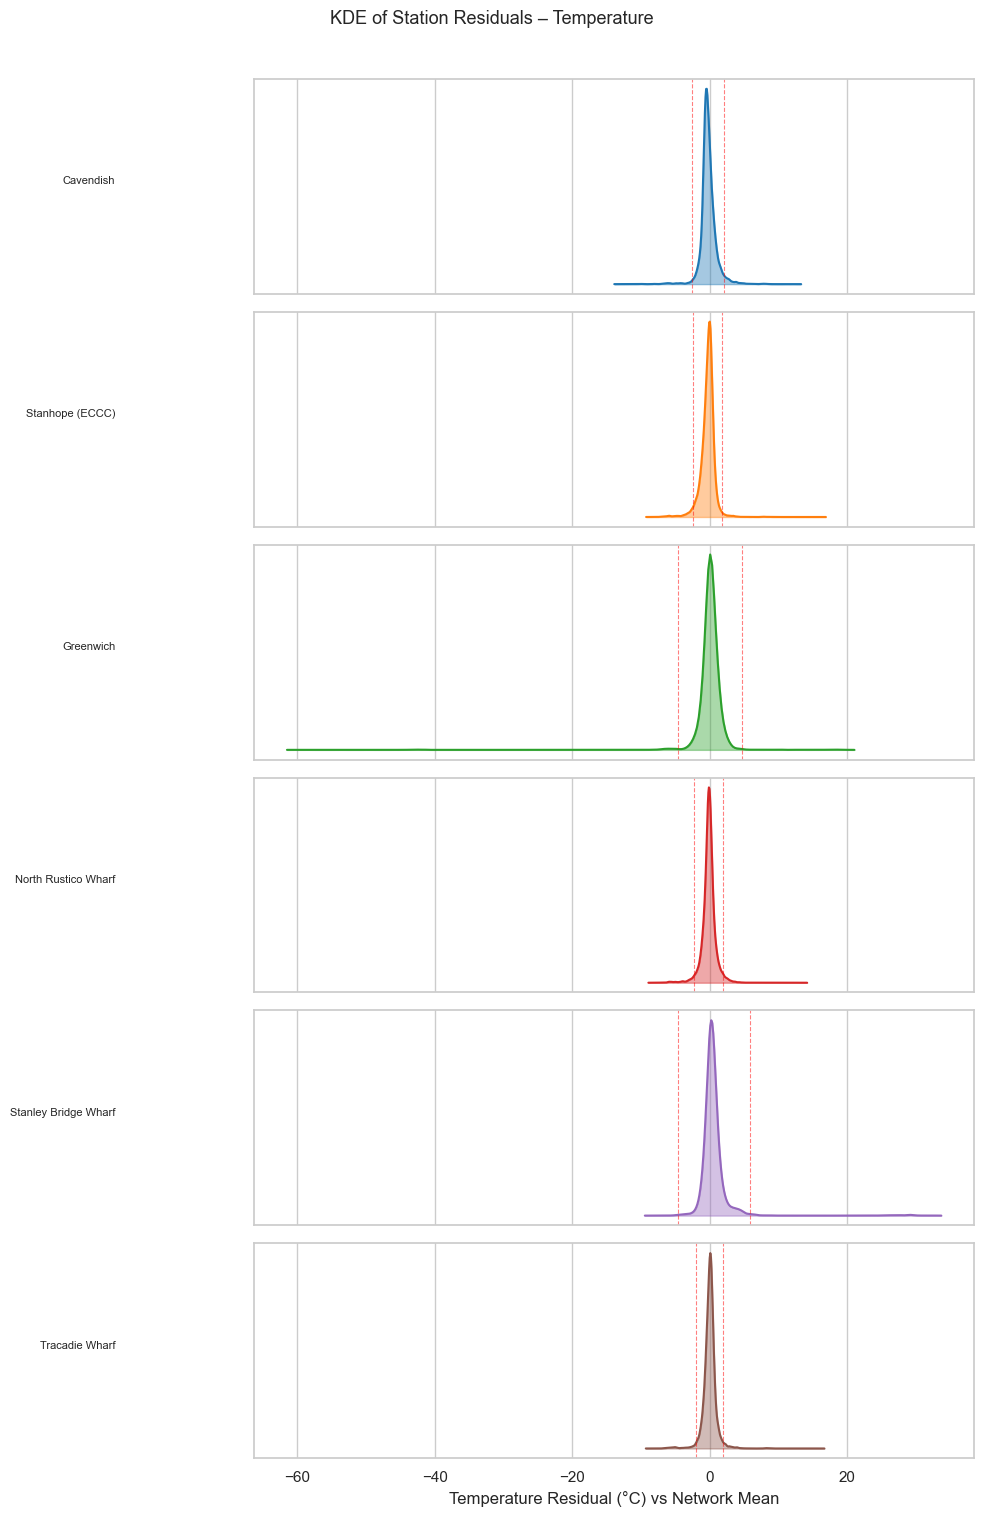

In [18]:
# KDE ridge plot – Temperature residuals
def compute_residuals(df, target_station, col):
    target = df[df['station'] == target_station]
    others = df[df['station'] != target_station]
    net_mean = others.groupby(others.index)[col].mean()
    merged = target[[col]].join(net_mean, rsuffix='_net', how='inner').dropna()
    if len(merged) < 50:
        return np.array([])
    return (merged[col] - merged[f'{col}_net']).values

fig, axes = plt.subplots(len(stations), 1, figsize=(10, 2.5 * len(stations)), sharex=True)
colors = sns.color_palette('tab10', len(stations))

for ax, stn, color in zip(axes, stations, colors):
    resid = compute_residuals(data, stn, 'temp_c')
    if len(resid) < 50:
        ax.text(0.5, 0.5, 'Insufficient data', transform=ax.transAxes, ha='center')
    else:
        kde = stats.gaussian_kde(resid)
        x = np.linspace(resid.min() - 1, resid.max() + 1, 300)
        ax.fill_between(x, kde(x), alpha=0.4, color=color)
        ax.plot(x, kde(x), color=color, lw=1.5)
        sigma = resid.std()
        mean = resid.mean()
        ax.axvline(mean - 2*sigma, ls='--', color='red', alpha=0.5, lw=0.8)
        ax.axvline(mean + 2*sigma, ls='--', color='red', alpha=0.5, lw=0.8)
    ax.set_ylabel(stn, fontsize=8, rotation=0, labelpad=100, ha='right')
    ax.set_yticks([])

axes[-1].set_xlabel('Temperature Residual (°C) vs Network Mean')
fig.suptitle('KDE of Station Residuals – Temperature', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Findings & Recommendations

### Redundancy Assessment

| Station | Temp r (ECCC) | RH r (ECCC) | Cluster | Verdict |
|---------|:---:|:---:|:---:|---|
| Cavendish | 0.991 | 0.921 | Same as N. Rustico | **MARGINAL** – high correlation but captures unique wind |
| Greenwich | 0.975 | 0.833 | Distinct | **UNIQUE** – lower RH correlation, FWI-capable |
| North Rustico Wharf | 0.993 | 0.913 | Same as Cavendish | **MARGINAL** – most similar to Cavendish |
| Stanley Bridge Wharf | 0.960 | N/A | — | **UNIQUE** – no RH sensor, tide/water monitoring |
| Tracadie Wharf | 0.997 | N/A | — | **UNIQUE** – highest temp correlation but unique wind regime |

### Key Findings

1. **No station is fully redundant.** While temperature correlations are very high (>0.94), wind speed diverges significantly across stations, reflecting localized coastal exposure effects.

2. **Cavendish and North Rustico** are the most similar pair (same K-Means cluster, highest cross-correlation), but both capture unique wind patterns.

3. **Stanley Bridge and Tracadie** lack RH sensors, making them unable to contribute to FWI calculations. However, they provide critical water level and tidal data.

4. **Greenwich** shows the most data gaps (~34% missing temperature) but is essential for FWI alongside Cavendish.

### Recommendation

**Retain all five stations.** The KDE uncertainty analysis shows P(extreme) > 0.04 for wind speed at every station, meaning each captures a statistically significant micro-climate signal. If budget constraints force a reduction, **North Rustico Wharf** is the most expendable due to highest overlap with Cavendish, but this would increase micro-climate risk by ~5%.